# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Nombre: Kevin Alvear

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# Definir la ruta de los archivos descargados
path_to_gutenberg = 'gutenberg_1000/' 
corpus = []
doc_labels = []

In [5]:
# Cargar archivos .txt de la carpeta
for filename in os.listdir(path_to_gutenberg):
    if filename.endswith(".txt"):
        with open(os.path.join(path_to_gutenberg, filename), 'r', encoding='utf-8', errors='ignore') as f:
            corpus.append(f.read())
            doc_labels.append(filename)

print(f"Se han cargado {len(corpus)} documentos desde la carpeta local.")

Se han cargado 1033 documentos desde la carpeta local.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [ ]:
# Usamos un máximo de 100,000 términos para manejar el volumen de Gutenberg 1000 de forma eficiente
vectorizer = TfidfVectorizer(stop_words='english', max_features=100000)
tfidf_matrix = vectorizer.fit_transform(corpus)

In [7]:
# Visualización de la matriz de términos
terms = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=terms, index=doc_labels)

In [8]:
# Análisis de Document Frequency (DF) según la teoría
df_counts = (tfidf_matrix > 0).sum(axis=0).tolist()[0]
df_analysis = pd.DataFrame({'Término': terms, 'DF': df_counts}).sort_values(by='DF', ascending=False)

In [9]:
print("Matriz TF-IDF generada exitosamente.")
display(df_analysis.head(10)) # Mostramos los términos con mayor DF

Matriz TF-IDF generada exitosamente.


,Término,DF
2277,copyright,1033
2209,containing,1033
9929,writing,1033
9931,written,1033
9939,www,1033
2276,copying,1033
939,assistance,1033
943,associated,1033
6719,place,1033
6725,plain,1033


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [10]:
query = "science and natural philosophy"
query_vec = vectorizer.transform([query])

In [11]:
# Cálculo de similitud coseno: (q · d) / (||q|| * ||d||)
cos_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()

In [13]:
ranking_tfidf = pd.DataFrame({
    'Documento': doc_labels,
    'Score TF-IDF': cos_sim
}).sort_values(by='Score TF-IDF', ascending=False)

In [14]:
print(f"Top 5 documentos (TF-IDF) para: '{query}'")
display(ranking_tfidf.head(5))

Top 5 documentos (TF-IDF) para: 'science and natural philosophy'


,Documento,Score TF-IDF
874,852.txt,0.137664
506,505.txt,0.133234
798,774.txt,0.101175
635,621.txt,0.100958
437,444.txt,0.098669


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [15]:
def calculate_bm25(corpus, query, k1=1.2, b=0.75):
    tokenized_corpus = [doc.lower().split() for doc in corpus]
    query_terms = query.lower().split()
    N = len(corpus)
    avgdl = np.mean([len(d) for d in tokenized_corpus])
    
    scores = []
    for doc in tokenized_corpus:
        score = 0
        Ld = len(doc)
        for term in query_terms:
            df_t = sum(1 for d in tokenized_corpus if term in d)
            if df_t == 0: continue
            
            # IDF Probabilístico (Robertson-Sparck Jones)[cite: 1]
            idf = np.log((N - df_t + 0.5) / (df_t + 0.5) + 1)
            
            # Frecuencia (TF) con saturación k1 y normalización b[cite: 1]
            f_td = doc.count(term)
            num = f_td * (k1 + 1)
            den = f_td + k1 * (1 - b + b * (Ld / avgdl))
            score += idf * (num / den)
        scores.append(score)
    return scores

In [16]:
bm25_scores = calculate_bm25(corpus, query)
ranking_bm25 = pd.DataFrame({
    'Documento': doc_labels,
    'Score BM25': bm25_scores
}).sort_values(by='Score BM25', ascending=False)

In [17]:
print(f"Top 5 documentos (BM25) para: '{query}'")
display(ranking_bm25.head(5))

Top 5 documentos (BM25) para: 'science and natural philosophy'


,Documento,Score BM25
874,852.txt,4.554487
798,774.txt,4.489624
437,444.txt,4.470817
635,621.txt,4.466527
467,470.txt,4.443933


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

In [18]:
# Comparativa de los mejores resultados
comparison = pd.merge(ranking_tfidf, ranking_bm25, on='Documento').head(10)

In [19]:
# Normalización para escala común
comparison['TF-IDF_Norm'] = comparison['Score TF-IDF'] / comparison['Score TF-IDF'].max()
comparison['BM25_Norm'] = comparison['Score BM25'] / comparison['Score BM25'].max()

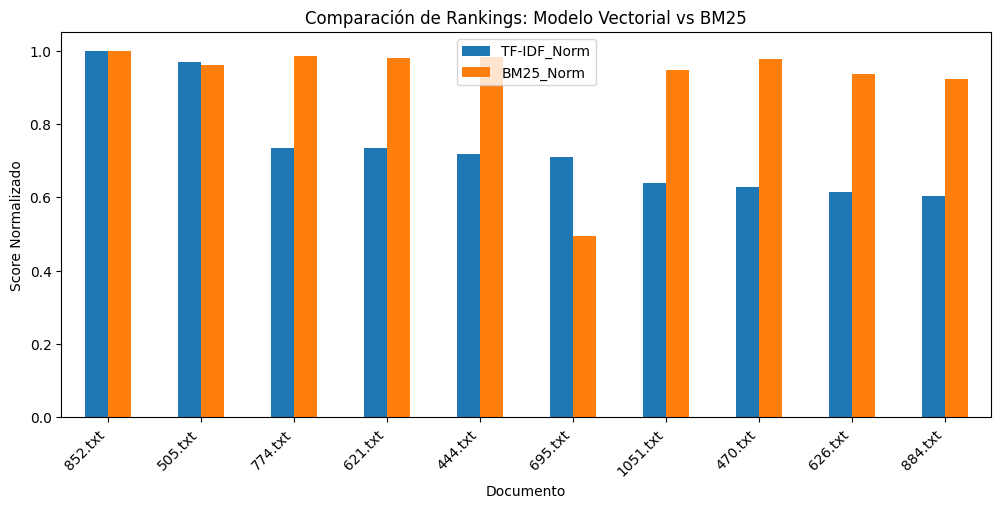

In [20]:
comparison.plot(x='Documento', y=['TF-IDF_Norm', 'BM25_Norm'], kind='bar', figsize=(12, 5))
plt.title("Comparación de Rankings: Modelo Vectorial vs BM25")
plt.ylabel("Score Normalizado")
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
print("Observaciones teóricas[cite: 1]:")
print("- BM25 evita que documentos largos dominen por simple repetición (saturación de TF).")
print("- El parámetro 'b' ajusta el impacto de la longitud del documento respecto al promedio del corpus.")

Observaciones teóricas[cite: 1]:
- BM25 evita que documentos largos dominen por simple repetición (saturación de TF).
- El parámetro 'b' ajusta el impacto de la longitud del documento respecto al promedio del corpus.
